# Results Table
Aggregates metrics from all project result files into a single table.
Each row is one project (framework + project name).

**Aggregation strategy:**
- **SonarQube**: taken directly from the project-level `sonarqube_project` field
- **Halstead** (raw counts + volume): summed across files
- **Halstead** (derived: difficulty, effort, time_seconds, bugs_delivered, calculated_length): median across files
- **State metrics** (mutable_vars, immutable_vars, observable_state_vars, state_updates): summed across files
- **Derived metrics** (mutable_variable_ratio, maintainability_index): median across files

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

COLORS = {'compose': '#4C72B0', 'views': '#DD8452'}  # blue / orange
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
RESULTS_DIR = Path('../results')

result_files = sorted(RESULTS_DIR.glob('*.json'))
print(f'Found {len(result_files)} result files:')
for f in result_files:
    print(f'  {f.name}')

Found 16 result files:
  compose_apps-android-wikipedia.json
  compose_compose.json
  compose_dicio.json
  compose_gallery.json
  compose_jetcaster.json
  compose_main.json
  compose_niacatalog.json
  compose_sunflower.json
  compose_tivi.json
  views_Simple-Gallery.json
  views_Simple-Music-Player.json
  views_architecture-samples-views.json
  views_dicio.json
  views_pokedex.json
  views_showly.json
  views_sunflower_views.json


In [3]:
SONARQUBE_FIELDS = [
    'ncloc', 'lines', 'files', 'functions', 'classes', 'statements',
    'complexity', 'cognitive_complexity',
    'code_smells', 'bugs', 'sqale_debt_ratio',
    'duplicated_lines_density', 'comment_lines', 'comment_lines_density',
]

# Summed: raw counts + volume (volume is additive in Halstead theory)
HALSTEAD_SUM_FIELDS = [
    'loc',
    'n1_unique_operators', 'n2_unique_operands',
    'N1_total_operators', 'N2_total_operands',
    'vocabulary', 'length', 'volume',
]

# Median: derived metrics that are not additive
HALSTEAD_MEDIAN_FIELDS = [
    'calculated_length', 'difficulty', 'effort',
    'time_seconds', 'bugs_delivered',
]

STATE_SUM_FIELDS = [
    'mutable_vars', 'immutable_vars',
    'observable_state_vars', 'state_updates',
]

DERIVED_MEDIAN_FIELDS = [
    'mutable_variable_ratio', 'maintainability_index',
]

# --- Project pairs ---
# Each entry: (fw_a, proj_a, display_color_a, fw_b, proj_b, display_color_b, bg_color)
# Project names match Path(project_path).name from the JSON files.
PAIRS = [
    ('compose', 'Gallery',                     COLORS['compose'], 'views', 'Simple-Gallery',              COLORS['views'], '#FFE4B5'),
    ('compose', 'nowinandroid',                COLORS['compose'], 'compose','apps-android-wikipedia',     COLORS['views'], '#B0E0E6'),  # wikipedia is views-dominant
    ('compose', 'Jetcaster',                   COLORS['compose'], 'views', 'Simple-Music-Player',         COLORS['views'], '#DDA0DD'),
    ('compose', 'sunflower',                   COLORS['compose'], 'views', 'sunflower_views',             COLORS['views'], '#ADDFAD'),
    ('compose', 'architecture-samples-compose',COLORS['compose'], 'views', 'architecture-samples-views',  COLORS['views'], '#F08080'),
    ('compose', 'pokedex-compose',             COLORS['compose'], 'views', 'Pokedex',                     COLORS['views'], '#FAFAD2'),
    ('compose', 'dicio-android',               COLORS['compose'], 'views', 'dicio-android-views',         COLORS['views'], '#E6E6FA'),
    ('compose', 'tivi',                        COLORS['compose'], 'views', 'showly',                      COLORS['views'], '#98FB98'),
]

In [4]:
def collect_file_values(files_dict, section, fields):
    """Collect non-null values for `fields` from a named sub-section of each file entry."""
    collected = {f: [] for f in fields}
    for file_data in files_dict.values():
        if not isinstance(file_data, dict):
            continue
        section_data = file_data.get(section, {})
        if not isinstance(section_data, dict):
            continue
        for field in fields:
            val = section_data.get(field)
            if val is not None:
                try:
                    collected[field].append(float(val))
                except (TypeError, ValueError):
                    pass
    return collected


def aggregate_project(data):
    row = {}
    # Use the last component of project_path as the canonical project name
    project_path = data.get('project_path', '')
    row['project']   = Path(project_path).name if project_path else data.get('project', '')
    row['framework'] = data.get('framework', '')

    sq = data.get('sonarqube_project', {})
    for field in SONARQUBE_FIELDS:
        val = sq.get(field)
        row[f'sq_{field}'] = float(val) if val is not None else None

    files_dict = data.get('files', {})

    hal = collect_file_values(files_dict, 'halstead', HALSTEAD_SUM_FIELDS + HALSTEAD_MEDIAN_FIELDS)
    for field in HALSTEAD_SUM_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = sum(vals) if vals else None
    for field in HALSTEAD_MEDIAN_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = float(np.median(vals)) if vals else None

    state = collect_file_values(files_dict, 'state_metrics', STATE_SUM_FIELDS)
    for field in STATE_SUM_FIELDS:
        vals = state[field]
        row[f'state_{field}'] = sum(vals) if vals else None

    derived = collect_file_values(files_dict, 'derived', DERIVED_MEDIAN_FIELDS)
    for field in DERIVED_MEDIAN_FIELDS:
        vals = derived[field]
        row[f'derived_{field}'] = float(np.median(vals)) if vals else None

    return row


rows = []
for result_file in result_files:
    with open(result_file) as f:
        data = json.load(f)
    rows.append(aggregate_project(data))

df = pd.DataFrame(rows).set_index(['framework', 'project'])
print(f'Table shape: {df.shape}')
print(df.index.tolist())
df

Table shape: (16, 33)
[('compose', 'apps-android-wikipedia'), ('compose', 'pokedex-compose'), ('compose', 'dicio-android'), ('compose', 'Gallery'), ('compose', 'Jetcaster'), ('compose', 'architecture-samples-compose'), ('compose', 'nowinandroid'), ('compose', 'sunflower'), ('compose', 'tivi'), ('views', 'Simple-Gallery'), ('views', 'Simple-Music-Player'), ('views', 'architecture-samples-views'), ('views', 'dicio-android-views'), ('views', 'Pokedex'), ('views', 'showly'), ('views', 'sunflower_views')]


sq_ncloc   sq_lines  sq_files  \
framework project                                                        
compose   apps-android-wikipedia       301904.000 324919.000  1966.000   
          pokedex-compose                4399.000   7825.000   151.000   
          dicio-android                 24579.000  29770.000   517.000   
          Gallery                       60908.000  68622.000   496.000   
          Jetcaster                     14927.000  21182.000   272.000   
          architecture-samples-compose   4285.000   7345.000    90.000   
          nowinandroid                  31420.000  44130.000   437.000   
          sunflower                      4046.000   6899.000   104.000   
          tivi                          26609.000  36630.000   748.000   
views     Simple-Gallery                41964.000  47194.000   293.000   
          Simple-Music-Player           16858.000  19722.000   253.000   
          architecture-samples-views     4495.000   7760.000    93.000   
          dicio-android-views            9798.000  11751.000   196.000   
          Pokedex                        2921.000   5521.000    97.000   
          showly                       112042.000 127743.000  2197.000   
          sunflower_views                3512.000   6380.000   122.000   

                                        sq_functions  sq_classes  \
framework project                                                  
compose   apps-android-wikipedia            6443.000    2066.000   
          pokedex-compose                    165.000      85.000   
          dicio-android                      782.000     296.000   
          Gallery                           1267.000     413.000   
          Jetcaster                          488.000     159.000   
          architecture-samples-compose       248.000      57.000   
          nowinandroid                       853.000     308.000   
          sunflower                          144.000      58.000   
          tivi                              1250.000     794.000   
views     Simple-Gallery                    1097.000     108.000   
          Simple-Music-Player                726.000     109.000   
          architecture-samples-views         350.000      50.000   
          dicio-android-views                332.000      95.000   
          Pokedex                            108.000      52.000   
          showly                            3703.000    1705.000   
          sunflower_views                    127.000      59.000   

                                        sq_statements  sq_complexity  \
framework project                                                      
compose   apps-android-wikipedia            37738.000      13565.000   
          pokedex-compose                     688.000        235.000   
          dicio-android                      4829.000       1656.000   
          Gallery                           11211.000       3435.000   
          Jetcaster                          2564.000        763.000   
          architecture-samples-compose       1272.000        306.000   
          nowinandroid                       4491.000       1231.000   
          sunflower                           702.000        193.000   
          tivi                               5143.000       2192.000   
views     Simple-Gallery                     9608.000       3869.000   
          Simple-Music-Player                4099.000       1485.000   
          architecture-samples-views         1488.000        433.000   
          dicio-android-views                2049.000        673.000   
          Pokedex                             398.000        146.000   
          showly                            23927.000       7685.000   
          sunflower_views                     456.000        164.000   

                                        sq_cognitive_complexity  \
framework project                                                 
compose   apps-android-wikipedia                    

## SonarQube metrics

In [5]:
sq_cols = [c for c in df.columns if c.startswith('sq_')]
df[sq_cols].rename(columns=lambda c: c[3:])

ncloc      lines    files  \
framework project                                                       
compose   apps-android-wikipedia       301904.000 324919.000 1966.000   
          pokedex-compose                4399.000   7825.000  151.000   
          dicio-android                 24579.000  29770.000  517.000   
          Gallery                       60908.000  68622.000  496.000   
          Jetcaster                     14927.000  21182.000  272.000   
          architecture-samples-compose   4285.000   7345.000   90.000   
          nowinandroid                  31420.000  44130.000  437.000   
          sunflower                      4046.000   6899.000  104.000   
          tivi                          26609.000  36630.000  748.000   
views     Simple-Gallery                41964.000  47194.000  293.000   
          Simple-Music-Player           16858.000  19722.000  253.000   
          architecture-samples-views     4495.000   7760.000   93.000   
          dicio-android-views            9798.000  11751.000  196.000   
          Pokedex                        2921.000   5521.000   97.000   
          showly                       112042.000 127743.000 2197.000   
          sunflower_views                3512.000   6380.000  122.000   

                                        functions  classes  statements  \
framework project                                                        
compose   apps-android-wikipedia         6443.000 2066.000   37738.000   
          pokedex-compose                 165.000   85.000     688.000   
          dicio-android                   782.000  296.000    4829.000   
          Gallery                        1267.000  413.000   11211.000   
          Jetcaster                       488.000  159.000    2564.000   
          architecture-samples-compose    248.000   57.000    1272.000   
          nowinandroid                    853.000  308.000    4491.000   
          sunflower                       144.000   58.000     702.000   
          tivi                           1250.000  794.000    5143.000   
views     Simple-Gallery                 1097.000  108.000    9608.000   
          Simple-Music-Player             726.000  109.000    4099.000   
          architecture-samples-views      350.000   50.000    1488.000   
          dicio-android-views             332.000   95.000    2049.000   
          Pokedex                         108.000   52.000     398.000   
          showly                         3703.000 1705.000   23927.000   
          sunflower_views                 127.000   59.000     456.000   

                                        complexity  cognitive_complexity  \
framework project                                                          
compose   apps-android-wikipedia         13565.000             10854.000   
          pokedex-compose                  235.000                96.000   
          dicio-android                   1656.000              1256.000   
          Gallery                         3435.000              4498.000   
          Jetcaster                        763.000               409.000   
          architecture-samples-compose     306.000                87.000   
          nowinandroid                    1231.000               592.000   
          sunflower                        193.000                63.000   
          tivi                            2192.000              1215.000   
views     Simple-Gallery                  3869.000              4114.000   
          Simple-Music-Player             1485.000              1187.000   
          architecture-samples-views       433.000               101.000   
          dicio-android-views              673.000               625.000   
          Pokedex                          146.000                39.000   
          showly                          7685.000              5179.000   
          sunflower_views                  164.000                36.000   

                           

## Halstead metrics

In [6]:
hal_cols = [c for c in df.columns if c.startswith('hal_')]
df[hal_cols].rename(columns=lambda c: c[4:])

loc  n1_unique_operators  \
framework project                                                        
compose   apps-android-wikipedia       104685.000            17024.000   
          pokedex-compose                5034.000              912.000   
          dicio-android                 18931.000             3489.000   
          Gallery                       45715.000             5854.000   
          Jetcaster                     16326.000             1704.000   
          architecture-samples-compose   5309.000              608.000   
          nowinandroid                  26544.000             3108.000   
          sunflower                      4313.000              669.000   
          tivi                          27493.000             6483.000   
views     Simple-Gallery                18217.000             1951.000   
          Simple-Music-Player            9199.000             1767.000   
          architecture-samples-views     5207.000              747.000   
          dicio-android-views            6193.000             1249.000   
          Pokedex                        2638.000              530.000   
          showly                        74152.000            15628.000   
          sunflower_views                2918.000              613.000   

                                        n2_unique_operands  \
framework project                                            
compose   apps-android-wikipedia                 85714.000   
          pokedex-compose                         2852.000   
          dicio-android                          13171.000   
          Gallery                                29669.000   
          Jetcaster                               8297.000   
          architecture-samples-compose            2509.000   
          nowinandroid                           12819.000   
          sunflower                               2460.000   
          tivi                                   19611.000   
views     Simple-Gallery                         12181.000   
          Simple-Music-Player                     8286.000   
          architecture-samples-views              2524.000   
          dicio-android-views                     4223.000   
          Pokedex                                 1543.000   
          showly                                 60285.000   
          sunflower_views                         1781.000   

                                        N1_total_operators  N2_total_operands  \
framework project                                                               
compose   apps-android-wikipedia                191464.000         212850.000   
          pokedex-compose                         5044.000           5567.000   
          dicio-android                          27587.000          33973.000   
          Gallery                                66750.000          75644.000   
          Jetcaster                              17789.000          20364.000   
          architecture-samples-compose            6373.000           6984.000   
          nowinandroid                           25586.000          29455.000   
          sunflower                               4331.000           4649.000   
          tivi                                   37712.000          40192.000   
views     Simple-Gallery                         35533.000          36491.000   
          Simple-Music-Player                    18917.000          19974.000   
          architecture-samples-views              7070.000           7115.000   
          dicio-android-views                     9290.000           9671.000   
          Pokedex                                 2640.000           2721.000   
          showly                                127927.000         139582.000   
          sunflower_views                         2798.000           2891.000   

                                        vocabulary     length      volume  \
framework project                                           

## State metrics (summed across files)

In [7]:
state_cols = [c for c in df.columns if c.startswith('state_')]
df[state_cols].rename(columns=lambda c: c[6:])

mutable_vars  immutable_vars  \
framework project                                                      
compose   apps-android-wikipedia            1760.000        6708.000   
          pokedex-compose                     18.000         126.000   
          dicio-android                      149.000        1161.000   
          Gallery                            363.000        3162.000   
          Jetcaster                           27.000         690.000   
          architecture-samples-compose        37.000         184.000   
          nowinandroid                       112.000         941.000   
          sunflower                           22.000         219.000   
          tivi                                58.000        1013.000   
views     Simple-Gallery                     544.000        1737.000   
          Simple-Music-Player                140.000         828.000   
          architecture-samples-views          47.000         278.000   
          dicio-android-views                102.000         388.000   
          Pokedex                             21.000          91.000   
          showly                             797.000        5126.000   
          sunflower_views                     22.000         123.000   

                                        observable_state_vars  state_updates  
framework project                                                             
compose   apps-android-wikipedia                      263.000       3536.000  
          pokedex-compose                               6.000         38.000  
          dicio-android                                42.000        349.000  
          Gallery                                     240.000        742.000  
          Jetcaster                                    40.000         69.000  
          architecture-samples-compose                 13.000         75.000  
          nowinandroid                                 39.000        233.000  
          sunflower                                     7.000         25.000  
          tivi                                         44.000        251.000  
views     Simple-Gallery                               15.000        986.000  
          Simple-Music-Player                          20.000        332.000  
          architecture-samples-views                   27.000        112.000  
          dicio-android-views                           0.000        240.000  
          Pokedex                                       1.000         21.000  
          showly                                      330.000       1798.000  
          sunflower_views                               5.000         24.000

## Derived metrics (median across files)

In [8]:
derived_cols = [c for c in df.columns if c.startswith('derived_')]
df[derived_cols].rename(columns=lambda c: c[8:])

mutable_variable_ratio  \
framework project                                                
compose   apps-android-wikipedia                         0.083   
          pokedex-compose                                0.000   
          dicio-android                                  0.000   
          Gallery                                        0.000   
          Jetcaster                                      0.000   
          architecture-samples-compose                   0.085   
          nowinandroid                                   0.000   
          sunflower                                      0.000   
          tivi                                           0.000   
views     Simple-Gallery                                 0.208   
          Simple-Music-Player                            0.125   
          architecture-samples-views                     0.148   
          dicio-android-views                            0.081   
          Pokedex                                        0.167   
          showly                                         0.000   
          sunflower_views                                0.000   

                                        maintainability_index  
framework project                                              
compose   apps-android-wikipedia                       36.990  
          pokedex-compose                              44.245  
          dicio-android                                41.410  
          Gallery                                      35.710  
          Jetcaster                                    35.680  
          architecture-samples-compose                 34.225  
          nowinandroid                                 39.680  
          sunflower                                    41.880  
          tivi                                         50.030  
views     Simple-Gallery                               34.995  
          Simple-Music-Player                          33.570  
          architecture-samples-views                   35.845  
          dicio-android-views                          41.345  
          Pokedex                                      42.240  
          showly                                       40.085  
          sunflower_views                              41.890

## Full table

In [9]:
df

sq_ncloc   sq_lines  sq_files  \
framework project                                                        
compose   apps-android-wikipedia       301904.000 324919.000  1966.000   
          pokedex-compose                4399.000   7825.000   151.000   
          dicio-android                 24579.000  29770.000   517.000   
          Gallery                       60908.000  68622.000   496.000   
          Jetcaster                     14927.000  21182.000   272.000   
          architecture-samples-compose   4285.000   7345.000    90.000   
          nowinandroid                  31420.000  44130.000   437.000   
          sunflower                      4046.000   6899.000   104.000   
          tivi                          26609.000  36630.000   748.000   
views     Simple-Gallery                41964.000  47194.000   293.000   
          Simple-Music-Player           16858.000  19722.000   253.000   
          architecture-samples-views     4495.000   7760.000    93.000   
          dicio-android-views            9798.000  11751.000   196.000   
          Pokedex                        2921.000   5521.000    97.000   
          showly                       112042.000 127743.000  2197.000   
          sunflower_views                3512.000   6380.000   122.000   

                                        sq_functions  sq_classes  \
framework project                                                  
compose   apps-android-wikipedia            6443.000    2066.000   
          pokedex-compose                    165.000      85.000   
          dicio-android                      782.000     296.000   
          Gallery                           1267.000     413.000   
          Jetcaster                          488.000     159.000   
          architecture-samples-compose       248.000      57.000   
          nowinandroid                       853.000     308.000   
          sunflower                          144.000      58.000   
          tivi                              1250.000     794.000   
views     Simple-Gallery                    1097.000     108.000   
          Simple-Music-Player                726.000     109.000   
          architecture-samples-views         350.000      50.000   
          dicio-android-views                332.000      95.000   
          Pokedex                            108.000      52.000   
          showly                            3703.000    1705.000   
          sunflower_views                    127.000      59.000   

                                        sq_statements  sq_complexity  \
framework project                                                      
compose   apps-android-wikipedia            37738.000      13565.000   
          pokedex-compose                     688.000        235.000   
          dicio-android                      4829.000       1656.000   
          Gallery                           11211.000       3435.000   
          Jetcaster                          2564.000        763.000   
          architecture-samples-compose       1272.000        306.000   
          nowinandroid                       4491.000       1231.000   
          sunflower                           702.000        193.000   
          tivi                               5143.000       2192.000   
views     Simple-Gallery                     9608.000       3869.000   
          Simple-Music-Player                4099.000       1485.000   
          architecture-samples-views         1488.000        433.000   
          dicio-android-views                2049.000        673.000   
          Pokedex                             398.000        146.000   
          showly                            23927.000       7685.000   
          sunflower_views                     456.000        164.000   

                                        sq_cognitive_complexity  \
framework project                                                 
compose   apps-android-wikipedia                    

---
# Plots

In [10]:
def build_plot_order(pairs, df):
    """
    Returns:
      order      - list of (framework, project) tuples in display order
      tick_labels- short project name for x-axis
      bar_colors - display bar color per entry (independent of df framework)
      bg_spans   - list of (x_start, x_end, color) for pair background shading
    """
    order, tick_labels, bar_colors, bg_spans = [], [], [], []
    x = 0
    for fw_a, proj_a, color_a, fw_b, proj_b, color_b, bg_color in pairs:
        group_start = x
        if (fw_a, proj_a) in df.index:
            order.append((fw_a, proj_a))
            tick_labels.append(proj_a)
            bar_colors.append(color_a)
            x += 1
        if fw_b is not None and (fw_b, proj_b) in df.index:
            order.append((fw_b, proj_b))
            tick_labels.append(proj_b)
            bar_colors.append(color_b)
            x += 1
        if x > group_start:
            bg_spans.append((group_start - 0.5, x - 0.5, bg_color))
    return order, tick_labels, bar_colors, bg_spans


def paired_bar(ax, col, ylabel, title, pairs, df, log=False):
    order, tick_labels, bar_colors, bg_spans = build_plot_order(pairs, df)
    values = [df.loc[key, col] if key in df.index else np.nan for key in order]

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.35, zorder=0)

    ax.bar(range(len(order)), values, color=bar_colors, zorder=3, width=0.6)

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.2, zorder=4)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log:
        ax.set_yscale('log')

    ax.legend(handles=[
        mpatches.Patch(color=COLORS['compose'], label='Compose'),
        mpatches.Patch(color=COLORS['views'],   label='Views'),
    ], fontsize=8)


print('Helper functions ready.')

Helper functions ready.


### SonarQube — complexity & size

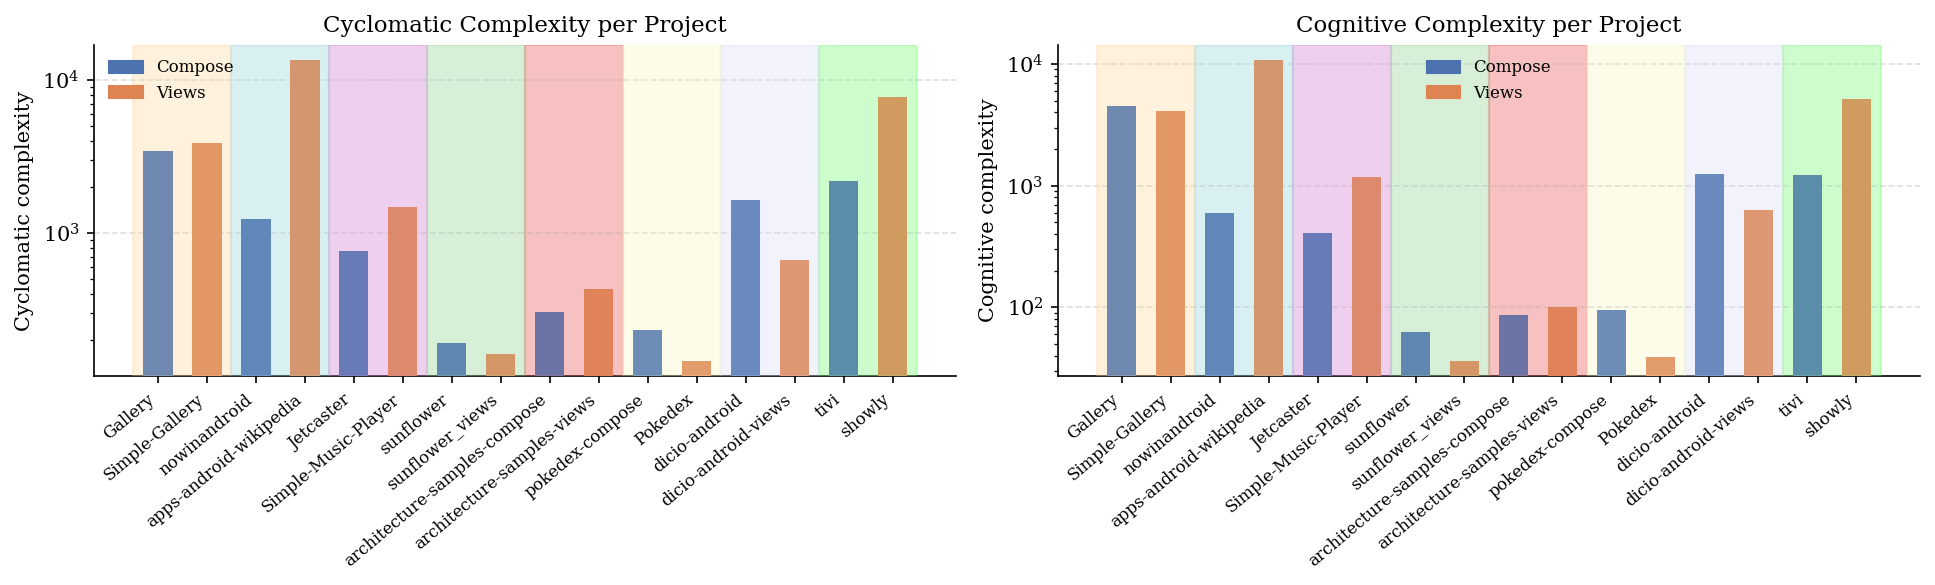

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_complexity',
           ylabel='Cyclomatic complexity',
           title='Cyclomatic Complexity per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_cognitive_complexity',
           ylabel='Cognitive complexity',
           title='Cognitive Complexity per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'complexity.pdf')
plt.show()

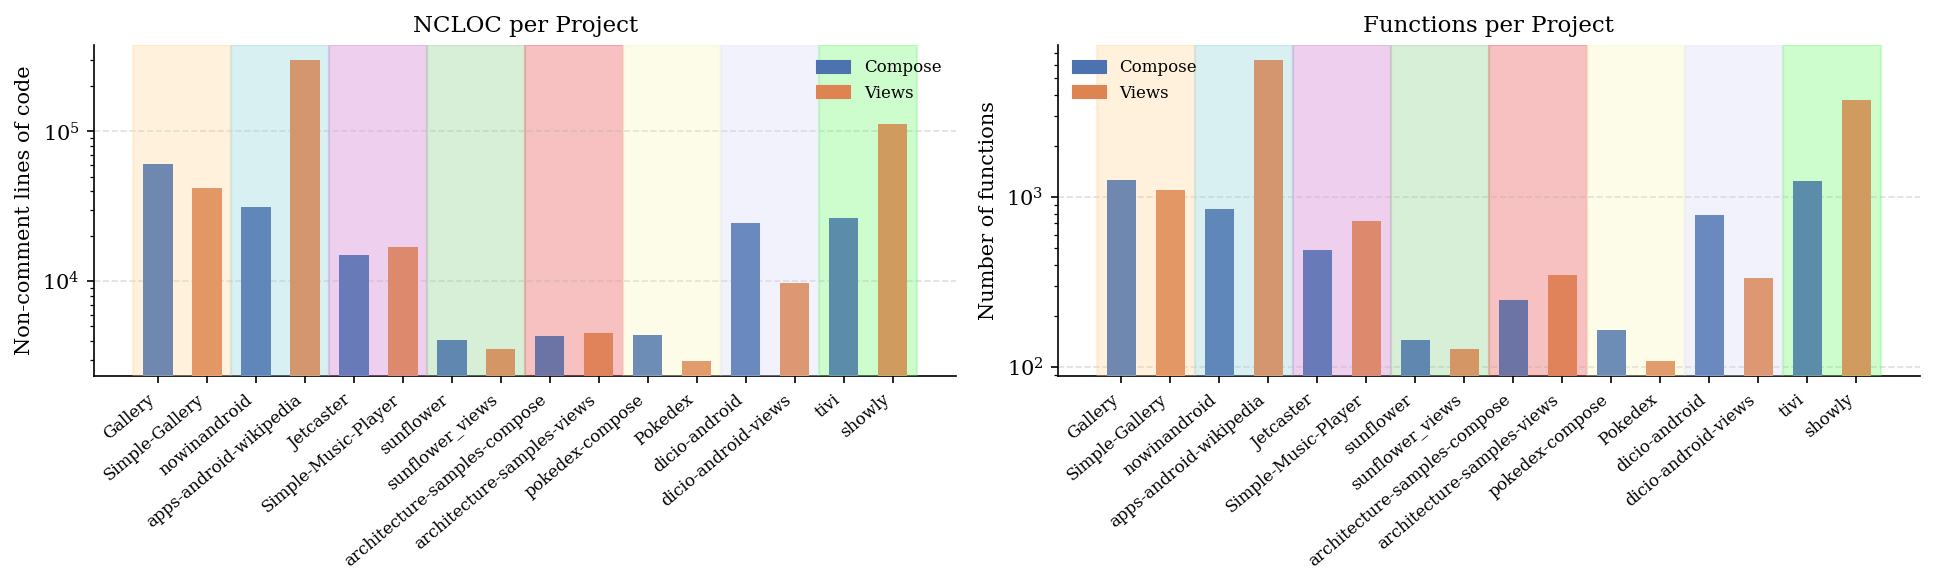

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_ncloc',
           ylabel='Non-comment lines of code',
           title='NCLOC per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_functions',
           ylabel='Number of functions',
           title='Functions per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'size.pdf')
plt.show()

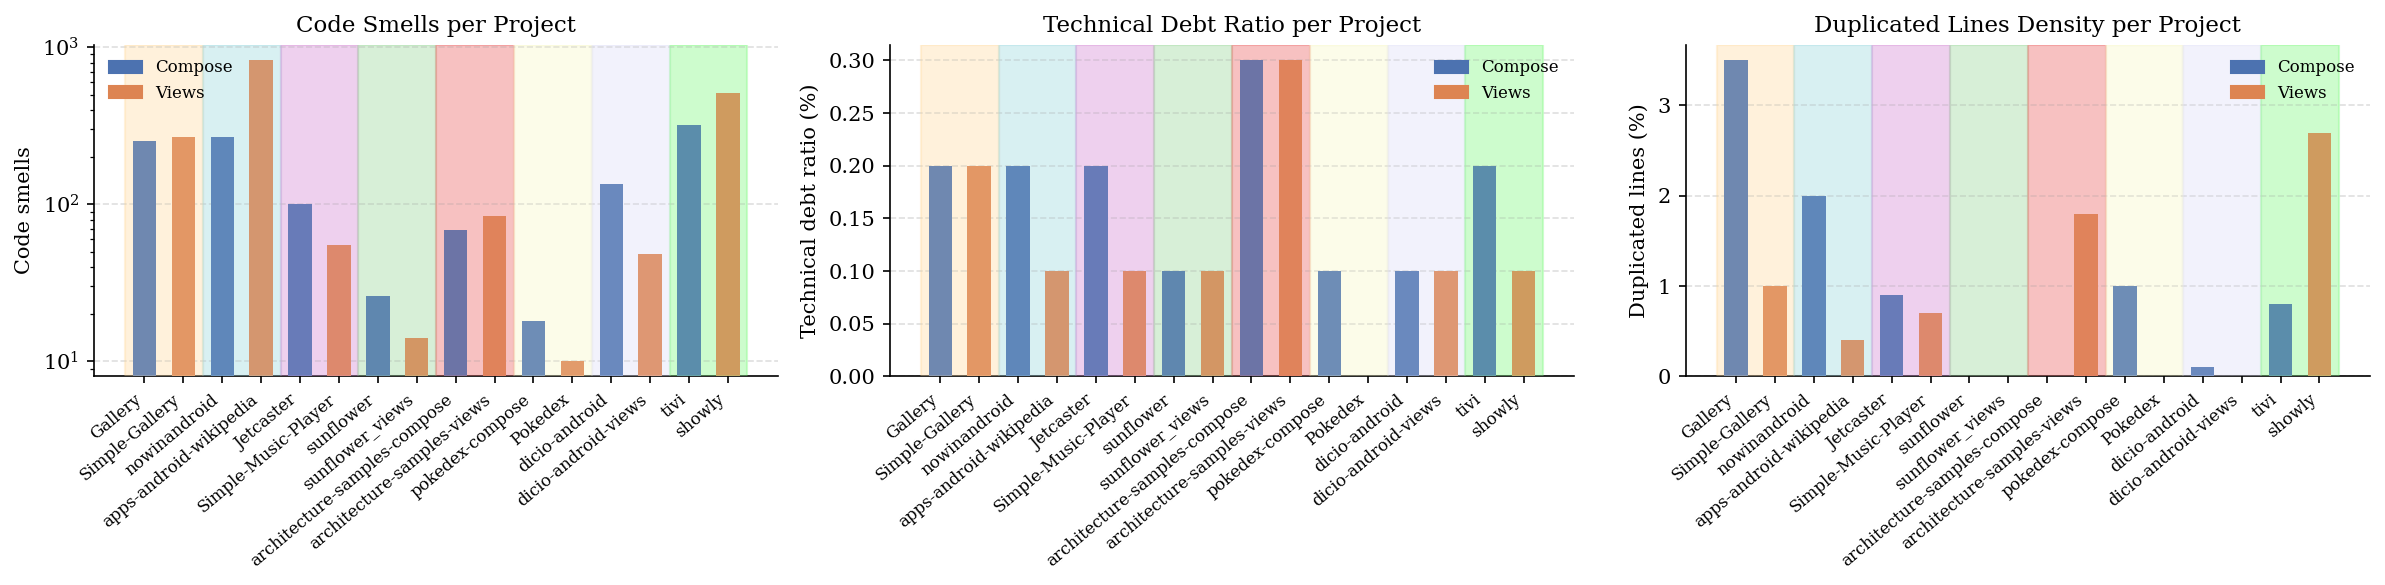

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'sq_code_smells',
           ylabel='Code smells',
           title='Code Smells per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_sqale_debt_ratio',
           ylabel='Technical debt ratio (%)',
           title='Technical Debt Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'sq_duplicated_lines_density',
           ylabel='Duplicated lines (%)',
           title='Duplicated Lines Density per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'quality.pdf')
plt.show()

### Halstead metrics

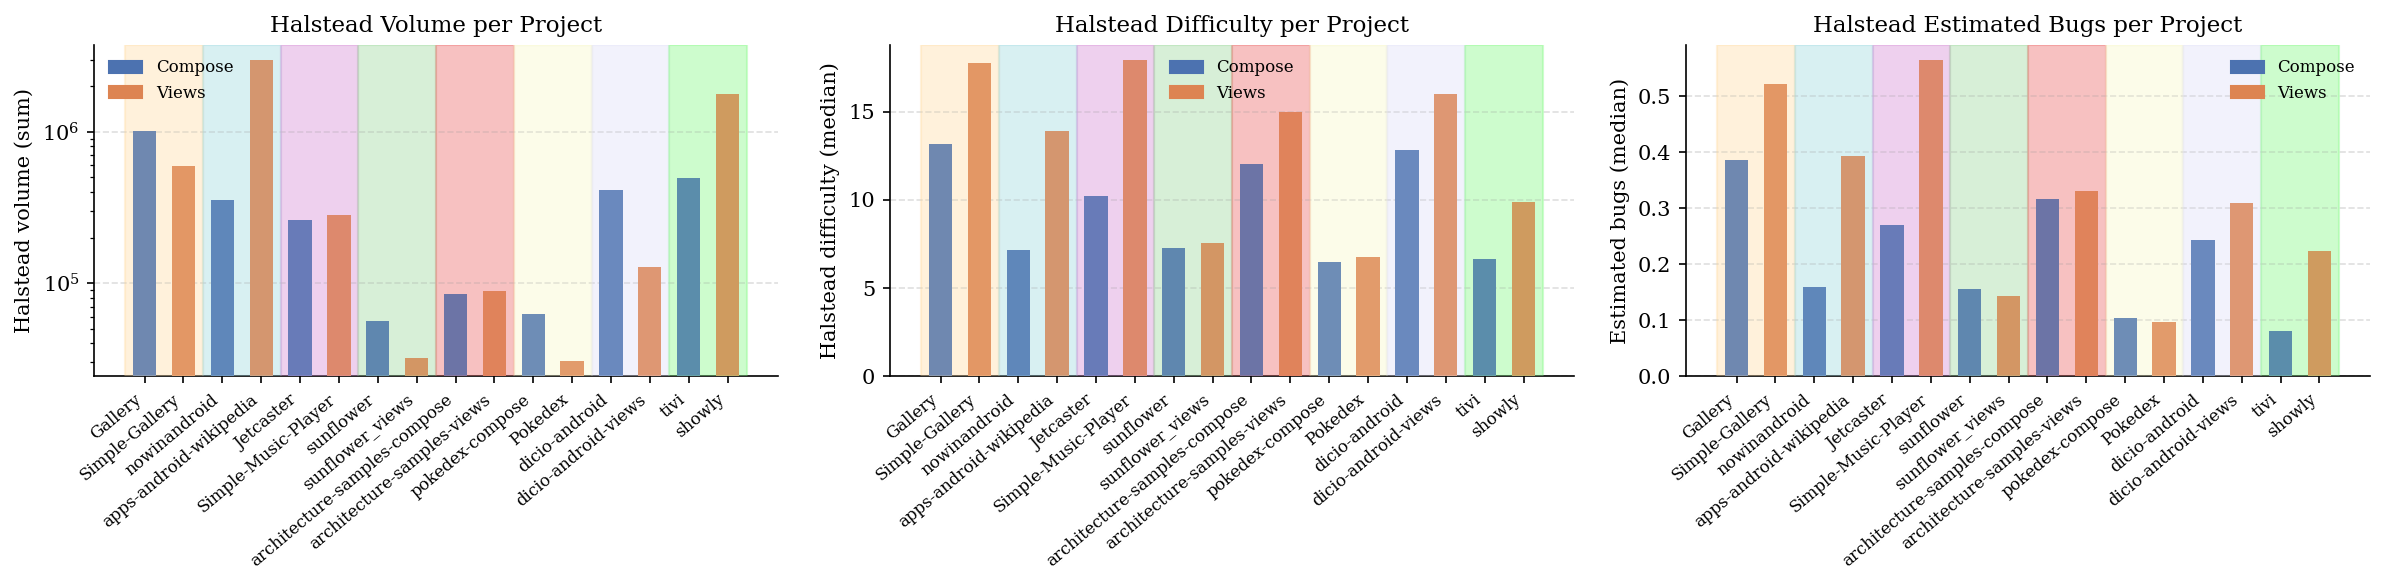

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'hal_volume',
           ylabel='Halstead volume (sum)',
           title='Halstead Volume per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'hal_difficulty',
           ylabel='Halstead difficulty (median)',
           title='Halstead Difficulty per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'hal_bugs_delivered',
           ylabel='Estimated bugs (median)',
           title='Halstead Estimated Bugs per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'halstead.pdf')
plt.show()

### State metrics

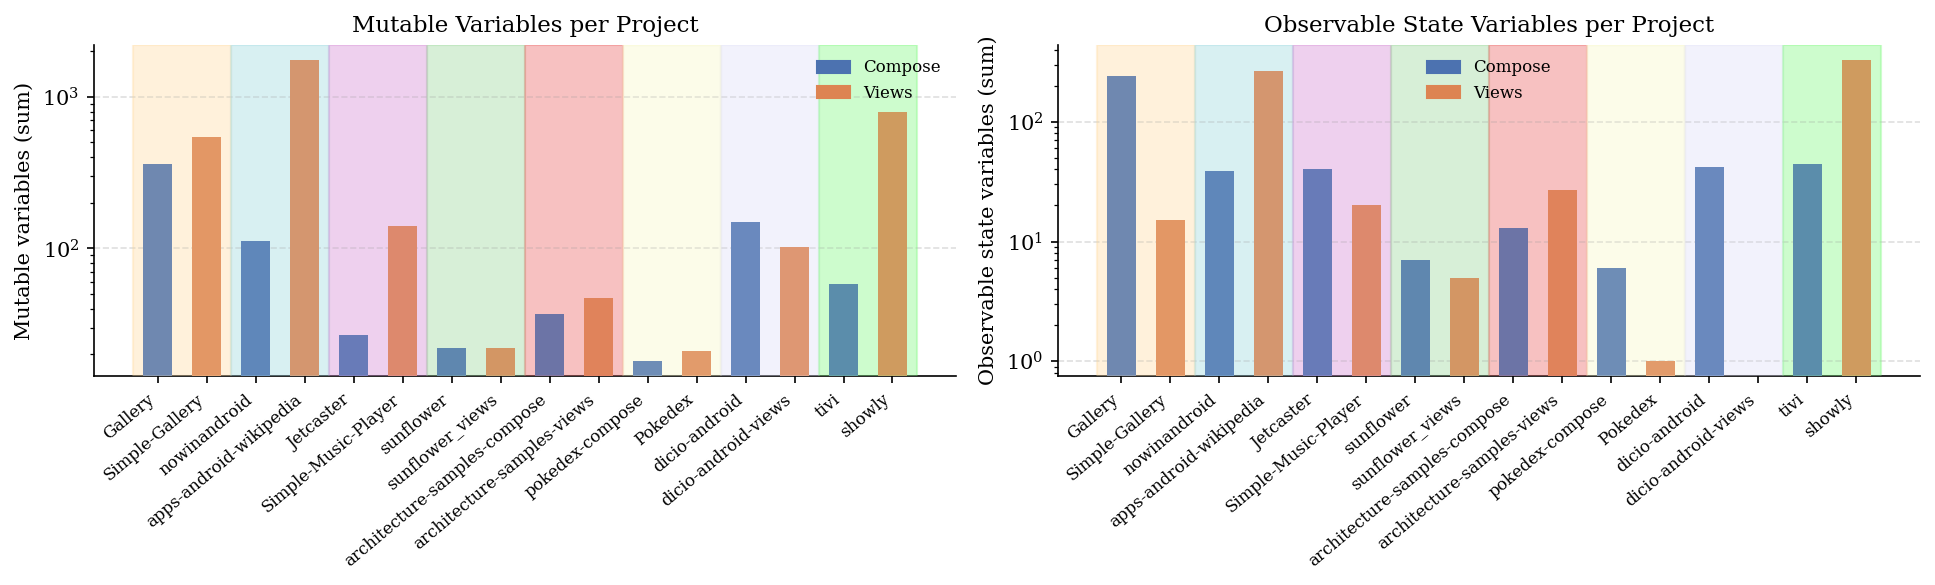

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'state_mutable_vars',
           ylabel='Mutable variables (sum)',
           title='Mutable Variables per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'state_observable_state_vars',
           ylabel='Observable state variables (sum)',
           title='Observable State Variables per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'state.pdf')
plt.show()

### Derived metrics

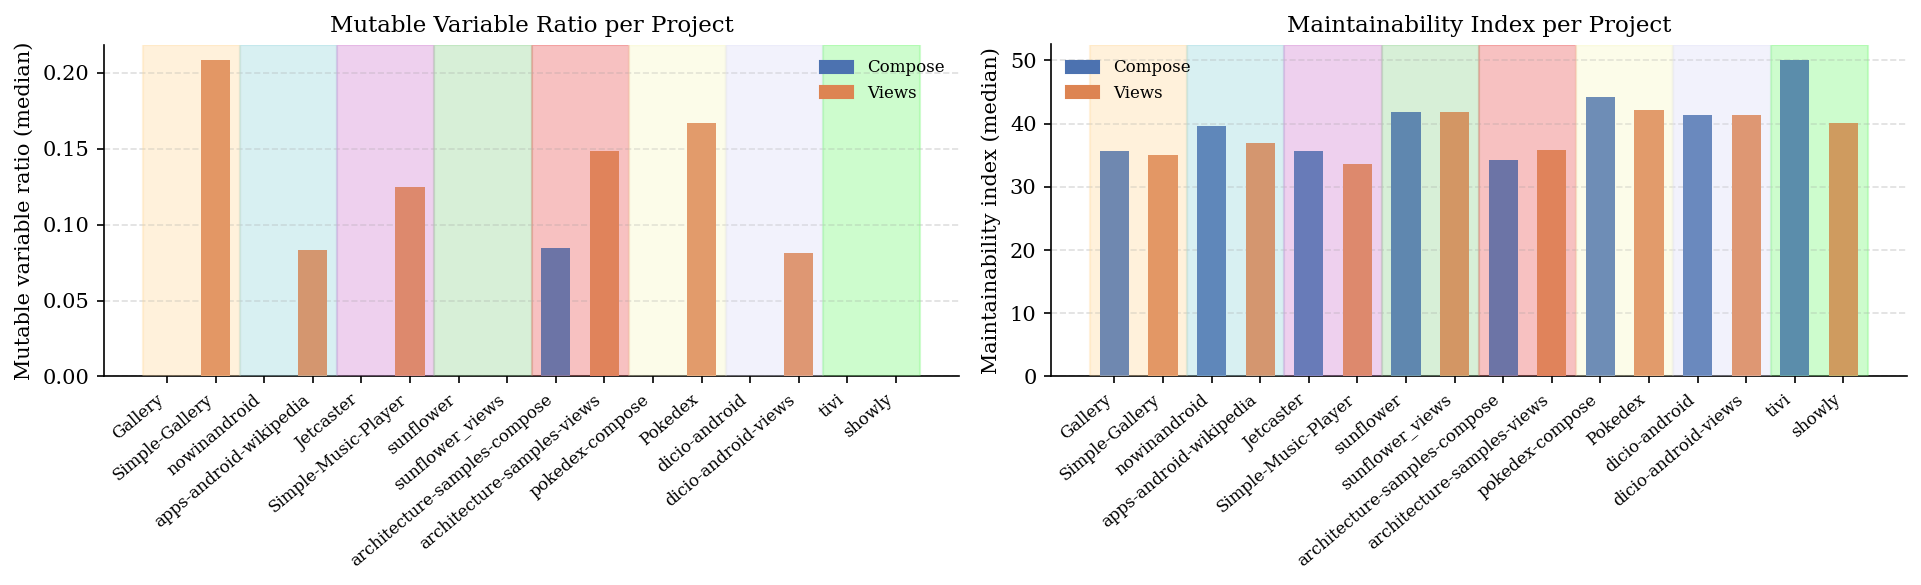

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'derived_mutable_variable_ratio',
           ylabel='Mutable variable ratio (median)',
           title='Mutable Variable Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[1], 'derived_maintainability_index',
           ylabel='Maintainability index (median)',
           title='Maintainability Index per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'derived.pdf')
plt.show()

## Export to CSV

In [17]:
out_path = RESULTS_DIR / 'metrics_table.csv'
df.to_csv(out_path)
print(f'Saved to {out_path}')

Saved to ../results/metrics_table.csv
